# FL Training Accuracy Curves
Loads `train_results_export.json` and plots validation accuracy over federated learning rounds for LeNet and ViT.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline

with open('train_results_export.json') as f:
    train_json = json.load(f)

SEEDS = [10, 20, 30]
FS = 10

CONDITIONS = [
    ('prune', 1.00, 'No Defense (α=1)',    'steelblue',     '-'),
    ('prune', 0.95, 'PLGP (α=0.95)',        'darkcyan',      '-'),
    ('prune', 0.90, 'PLGP (α=0.90)',        'mediumseagreen','-'),
    ('prune', 0.05, 'PLGP best (α=0.05)',   'seagreen',      '-.'),
    ('prune', 0.00, 'Strict LGP (α=0)',     'darkorange',    ':'),
    ('clip',  1.00, 'Gradient Clipping',    'tomato',        '--'),
]

def mean_curve(model, method, alpha):
    curves = []
    for seed in SEEDS:
        key = f'{model}_{method}_{alpha:.2f}_{seed}'
        entry = train_json.get(key)
        if entry and entry.get('val_accuracy'):
            curves.append(entry['val_accuracy'])
    if not curves:
        return None
    max_len = max(len(c) for c in curves)
    mat = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves):
        mat[i, :len(c)] = c
    return np.nanmean(mat, axis=0)

## LeNet — Validation Accuracy over FL Rounds

In [ ]:
import os
fig, ax = plt.subplots(figsize=(7, 4))
for method, alpha, label, color, ls in CONDITIONS:
    curve = mean_curve('lenet', method, alpha)
    if curve is None:
        continue
    ax.plot(np.arange(1, len(curve)+1), curve, label=label, color=color, linestyle=ls, linewidth=1.5)
ax.set_xlabel('Global Round', fontsize=FS)
ax.set_ylabel('Test Accuracy', fontsize=FS)
ax.set_title('Test Accuracy over FL Rounds  [LENET]', fontsize=FS+1)
ax.legend(fontsize=FS-1)
ax.grid(True, linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/lenet_accuracy_rounds.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/lenet_accuracy_rounds.pdf")

## LeNet — Train vs Val Accuracy Panel

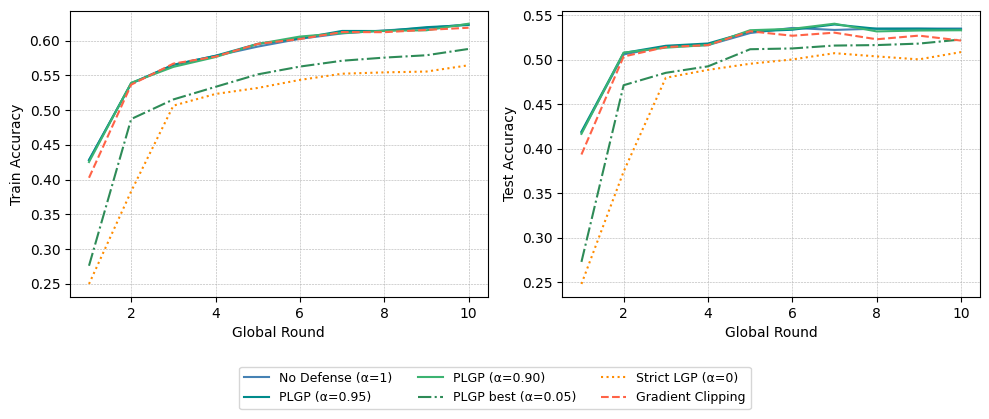

In [3]:
fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
lines, labels = [], []

for method, alpha, label, color, ls in CONDITIONS:
    train_curves, val_curves = [], []
    for seed in SEEDS:
        entry = train_json.get(f'lenet_{method}_{alpha:.2f}_{seed}')
        if not entry:
            continue
        if entry.get('train_accuracy'):
            train_curves.append(entry['train_accuracy'])
        if entry.get('val_accuracy'):
            val_curves.append(entry['val_accuracy'])

    def _mean(curves):
        if not curves: return None
        max_len = max(len(c) for c in curves)
        mat = np.full((len(curves), max_len), np.nan)
        for i, c in enumerate(curves): mat[i, :len(c)] = c
        return np.nanmean(mat, axis=0)

    t, v = _mean(train_curves), _mean(val_curves)
    rounds = np.arange(1, (len(t) if t is not None else len(v)) + 1)
    if t is not None:
        line, = ax1.plot(rounds, t, label=label, color=color, linestyle=ls, linewidth=1.5)
        lines.append(line); labels.append(label)
    if v is not None:
        ax2.plot(rounds, v, color=color, linestyle=ls, linewidth=1.5)

ax1.set_xlabel('Global Round', fontsize=FS); ax1.set_ylabel('Train Accuracy', fontsize=FS)
ax1.grid(True, linestyle='--', linewidth=0.4); ax1.tick_params(labelsize=FS)
ax2.set_xlabel('Global Round', fontsize=FS); ax2.set_ylabel('Test Accuracy', fontsize=FS)
ax2.grid(True, linestyle='--', linewidth=0.4); ax2.tick_params(labelsize=FS)
if lines:
    fig.legend(handles=lines, labels=labels, loc='lower center', ncol=3,
               fontsize=FS-1, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

## ViT — Final Validation Accuracy per Condition (seed=10)

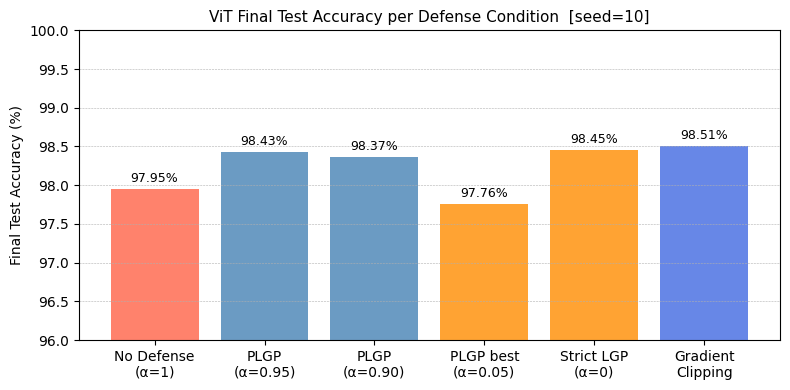

In [4]:
vit_conditions = [
    ('prune', 1.00, 'No Defense\n(α=1)',    'tomato'),
    ('prune', 0.95, 'PLGP\n(α=0.95)',       'steelblue'),
    ('prune', 0.90, 'PLGP\n(α=0.90)',       'steelblue'),
    ('prune', 0.05, 'PLGP best\n(α=0.05)',  'darkorange'),
    ('prune', 0.00, 'Strict LGP\n(α=0)',    'darkorange'),
    ('clip',  1.00, 'Gradient\nClipping',   'royalblue'),
]

labels, vals, colors = [], [], []
for method, alpha, label, color in vit_conditions:
    key = f'vit_{method}_{alpha:.2f}_10'
    entry = train_json.get(key)
    if entry and entry.get('val_accuracy'):
        labels.append(label)
        vals.append(entry['val_accuracy'][-1] * 100)
        colors.append(color)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(vals)), vals, color=colors, alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=FS-1)
ax.set_ylabel('Final Test Accuracy (%)', fontsize=FS)
ax.set_title('ViT Final Test Accuracy per Defense Condition  [seed=10]', fontsize=FS+1)
ax.set_ylim(96, 100)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=FS-1)
plt.tight_layout()
plt.show()

## ViT — Validation Accuracy over FL Rounds (seed=10)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for method, alpha, label, color, ls in CONDITIONS:
    key = f'vit_{method}_{alpha:.2f}_10'
    entry = train_json.get(key)
    if not entry or not entry.get('val_accuracy'):
        continue
    va = entry['val_accuracy']
    ax.plot(np.arange(1, len(va)+1), va, label=label, color=color, linestyle=ls, linewidth=1.5)
ax.set_xlabel('Global Round', fontsize=FS)
ax.set_ylabel('Test Accuracy', fontsize=FS)
ax.set_title('Test Accuracy over FL Rounds  [VIT, seed=10]', fontsize=FS+1)
ax.legend(fontsize=FS-1)
ax.grid(True, linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
plt.tight_layout()
plt.savefig("figures/vit_accuracy_rounds.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/vit_accuracy_rounds.pdf")